In [20]:
import numpy as np
import os
import sys
import pandas as pd

In [12]:
sys.path.append(r"E:\ICA_SVAR\EMD_ICA")

In [13]:
from eemd_ica.pipeline import EEMDICAPipeline
from eemd_ica.plotting import (
    plot_imfs,
    plot_cci_bar,
    plot_components,
    plot_verification_heatmap,
)


In [14]:
# ---------------------------------------------------------------------------
np.random.seed(0)
T = 500

t = np.linspace(0, 4 * np.pi, T)

# Simulate: trend + business cycle + short-cycle + noise
trend      = 0.05 * t + 50
cycle_long = 8 * np.sin(t)
cycle_short= 3 * np.sin(4 * t + 0.5)
noise      = np.random.normal(0, 1.5, T)

prices = trend + cycle_long + cycle_short + noise
prices = np.abs(prices)  # keep prices positive

print(f"Synthetic price series: T={T}, range=[{prices.min():.2f}, {prices.max():.2f}]")

Synthetic price series: T=500, range=[37.30, 63.92]


In [15]:
gdp_growth = 0.003 * t + np.random.normal(0, 0.01, T)  # noisy upward trend

In [22]:
pipeline = EEMDICAPipeline(
    ensemble_size=50,          # reduce for faster demo; use 100+ in practice
    noise_std=0.2,
    rhd_threshold=0.3,
    n_components=2,         # auto-select
    use_log_returns=True,
    standardise_input=True,
    detect_structural_break=True,
    verbose=True,
)

results = pipeline.fit(
    time_series=prices,
    proxy_variables=gdp_growth,
    proxy_names=["GDP_growth"],
)

EEMD-ICA Factor Analysis Pipeline

[Stage I]  Preprocessing  (T=500)
           → Log returns computed  (T=499)
           → Standardised  (μ=-0.0001, σ=0.0435)
           → Structural break: bp=327 (F=0.95, p=0.3874)
           → Proxy variables aligned  (T=499)

[Stage III] EEMD Decomposition  (ensemble_size=50)
           → 7 IMFs extracted (incl. residual)

[Stage IV] RHD Integration  (threshold=0.3)
           → 2 VIMFs retained
RHD Integration Summary
  IMF-1         CCI=+0.9598  [KEPT]
  IMF-2         CCI=-0.0241  [MERGED]
  IMF-3         CCI=-0.0361  [MERGED]
  IMF-4         CCI=+0.0361  [MERGED]
  IMF-5         CCI=+0.0241  [MERGED]
  IMF-6         CCI=+0.0000  [MERGED]
  residual      CCI=+0.0161  [KEPT]

  Threshold : 0.3
  VIMFs kept: 2
  Merged    : 5

[Stage V]  FastICA Source Separation
           → 2 ICs extracted
ICA Source Separation Summary
  IC-01  b_k=+0.9593  std=1.0000  skew=+0.0887
  IC-02  b_k=-0.0169  std=1.0000  skew=+0.2140

[Stage VI] Statistical Verificati

In [23]:
print(pipeline.summary())


EEMD-ICA Pipeline Summary

RHD Integration Summary
  IMF-1         CCI=+0.9598  [KEPT]
  IMF-2         CCI=-0.0241  [MERGED]
  IMF-3         CCI=-0.0361  [MERGED]
  IMF-4         CCI=+0.0361  [MERGED]
  IMF-5         CCI=+0.0241  [MERGED]
  IMF-6         CCI=+0.0000  [MERGED]
  residual      CCI=+0.0161  [KEPT]

  Threshold : 0.3
  VIMFs kept: 2
  Merged    : 5

ICA Source Separation Summary
  IC-01  b_k=+0.9593  std=1.0000  skew=+0.0887
  IC-02  b_k=-0.0169  std=1.0000  skew=+0.2140

IC Verification Summary
  IC |   JB p-val  Non-Gauss |   Hurst  Memory |    Corr |      R²   Sig
------------------------------------------------------------------------
   1 |   2.94e-02       True |  0.4221   False |  0.9416 | -0.0003 False
   2 |   2.69e-07       True |  1.0688    True |  0.0090 |  0.1189  True

Elapsed times:
  preprocessing       :   0.12s
  eemd                :   0.27s
  integration         :   0.00s
  ica                 :   0.01s
  verification        :   0.02s


In [24]:
components = results["components"] 
components_df = pd.DataFrame(components)

print(components_df.head())
print(f"Extracted {len(components)} independent factors")

        0         1         2         3         4         5         6    \
0 -0.339917  1.402897  1.752852  0.457196 -1.588744  1.313702 -0.826997   
1  0.352988  0.387926  0.402442  0.392900  0.372196  0.422411  0.399642   

        7         8         9    ...       489       490       491       492  \
0 -0.060220  0.289471 -0.384494  ... -0.505251  0.440662  0.455478 -0.545557   
1  0.418401  0.430810  0.428133  ...  1.663972  1.671954  1.666152  1.645342   

        493       494       495       496       497       498  
0  0.916027 -1.282090  0.360134  0.679943 -0.132337  0.791881  
1  1.659620  1.620807  1.636919  1.633597  1.613580  1.618179  

[2 rows x 499 columns]
Extracted 2 independent factors


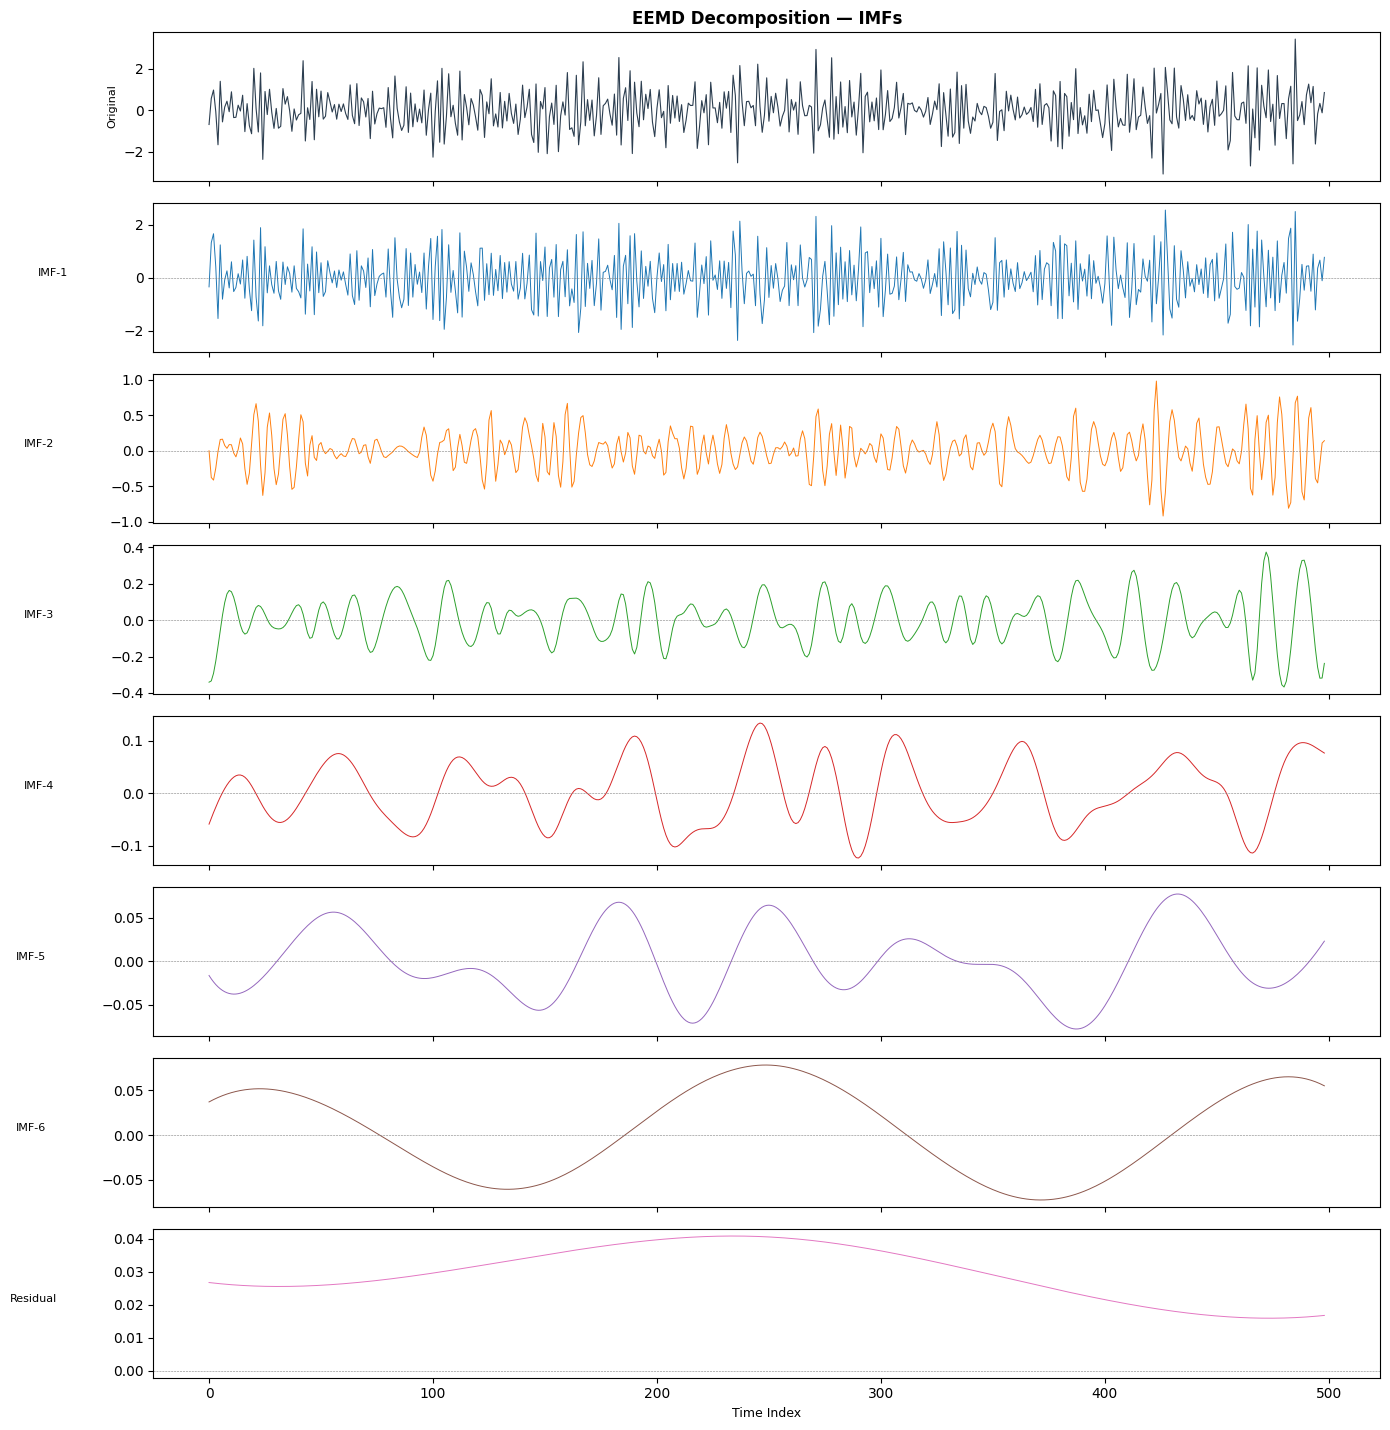

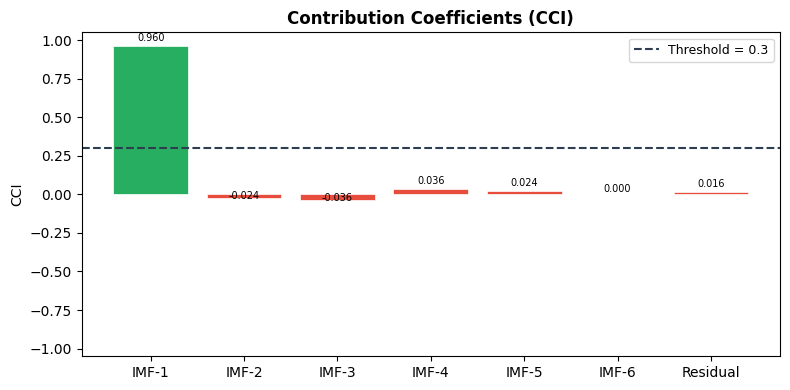

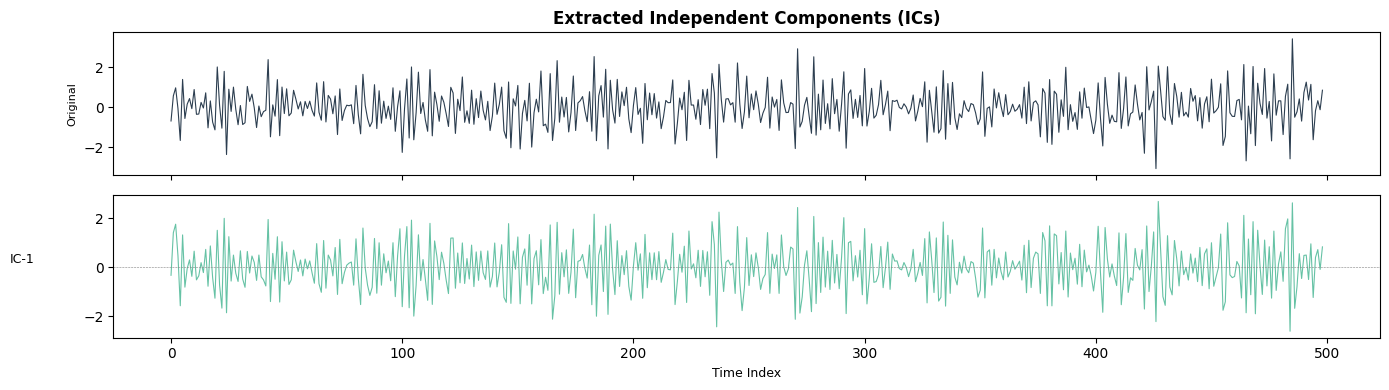

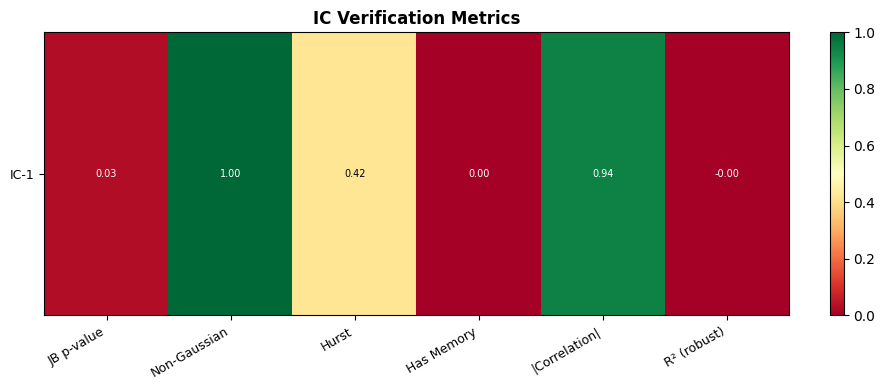

In [26]:
# ---------------------------------------------------------------------------
# 4. Plot results
# ---------------------------------------------------------------------------
try:
    import matplotlib.pyplot as plt

    # IMF decomposition
    fig1 = plot_imfs(results["imfs"], original=results["preprocessed_series"])
    #fig1.savefig("imfs.png", dpi=150)
    #print("\nSaved: imfs.png")

    # CCI bar chart
    fig2 = plot_cci_bar(results["ccis"], threshold=pipeline.rhd_threshold)
    #fig2.savefig("cci.png", dpi=150)
    #print("Saved: cci.png")

    # Independent components
    fig3 = plot_components(results["components"], original=results["preprocessed_series"])
    #fig3.savefig("components.png", dpi=150)
    #print("Saved: components.png")

    # Verification heatmap
    fig4 = plot_verification_heatmap(results["verification"])
    #fig4.savefig("verification.png", dpi=150)
    #print("Saved: verification.png")

    plt.show()

except ImportError:
    print("\nmatplotlib not installed — skipping plots.")

In [1]:
print(pipeline.summary())

NameError: name 'pipeline' is not defined